# Solutions · 10 · UNIFAC: predicting activity coefficients

Worked solutions to the exercises of [notebook 10](../notebooks/10_unifac_prediction.ipynb). Try each exercise
yourself before reading its solution - the learning happens in the attempt. Solutions are one way to
answer each question; other correct approaches exist.

In [1]:
try:                      # on Google Colab (or anywhere engthermo is missing): install it from GitHub
    import engthermo
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/ktwyw/engthermo"], check=True)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from engthermo import activity, datasets, unifac, vle
plt.rcParams.update({"figure.figsize": (7, 4), "figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

import inspect
from IPython.display import Code

def show_source(obj):
    """Display the source code of a library function or class."""
    return Code(inspect.getsource(obj), language="python")

def heading(text):
    print(f"\n{text}\n" + "=" * len(text))

## Exercise 1

Predict the T-x-y diagram of acetone-methanol at 1 atm with UNIFAC and locate its azeotrope. (Experimental: about 0.80 mole fraction acetone at 55.7 degC.)

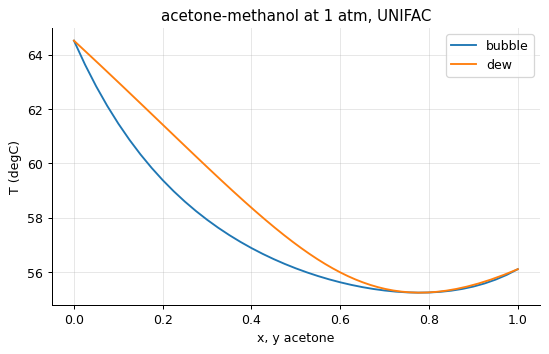

UNIFAC azeotrope: x_acetone = 0.779 at 55.2 degC  (experimental about 0.80 at 55.7 degC)


In [2]:
comps = ["acetone", "methanol"]
g = unifac.gamma_function(comps)
d = vle.Txy(comps, 101325.0, g, n=41)
plt.plot(d["x1"], d["T"] - 273.15, label="bubble"); plt.plot(d["y1"], d["T"] - 273.15, label="dew")
plt.xlabel("x, y acetone"); plt.ylabel("T (degC)"); plt.title("acetone-methanol at 1 atm, UNIFAC"); plt.legend(); plt.show()
az = activity.azeotrope(comps, g, p=101325.0)
print(f"UNIFAC azeotrope: x_acetone = {az['x1']:.3f} at {az['T']-273.15:.1f} degC  (experimental about 0.80 at 55.7 degC)")

UNIFAC predicts the minimum-boiling azeotrope of acetone-methanol within a few hundredths in composition
and a degree in temperature, again from group parameters alone.

## Exercise 2

Use UNIFAC to rank benzene, toluene, n-hexane and 1-butanol as solvents for extracting ethanol from water at 25 degC, and comment on the trade-off between affinity and the solvent's own solubility in water.

In [3]:
rows = []
for solvent in ("benzene", "toluene", "n-hexane", "1-butanol"):
    g_e = activity.infinite_dilution(unifac.gamma_function(["ethanol", solvent]), 298.15)[0]
    g_w = activity.infinite_dilution(unifac.gamma_function(["water", solvent]), 298.15)[0]
    rows.append((solvent, g_e, activity.infinite_dilution(unifac.gamma_function(["ethanol", "water"]), 298.15)[0] / g_e, g_w))
print(pd.DataFrame(rows, columns=["solvent", "gamma_inf ethanol in solvent", "distribution coefficient", "gamma_inf water in solvent"]).round(2).to_string(index=False))

  solvent  gamma_inf ethanol in solvent  distribution coefficient  gamma_inf water in solvent
  benzene                         10.84                      0.70                      439.87
  toluene                          9.89                      0.77                      646.02
 n-hexane                         27.71                      0.28                     1403.57
1-butanol                          1.04                      7.32                        3.80


Butanol has by far the best affinity for ethanol (its OH group), but water's activity coefficient in butanol
is small too: butanol dissolves a lot of water and is itself soluble in water (notebook 12), so the extract is
wet and solvent is lost. The hydrocarbons extract poorly but stay cleanly separated. Extraction solvent
selection is a trade-off between affinity for the solute and rejection of the carrier.

## Exercise 3

**Implement it yourself:** compute the infinite-dilution activity coefficient of ethanol in water at 351 K by evaluating UNIFAC at x = 1e-6, and compare with the value extracted from the data file's first points.

In [4]:
ginf = unifac.gammas(["ethanol", "water"], [1e-6, 1 - 1e-6], 351.0)[0]
d = pd.read_csv(datasets.path("ethanol_water_vle_1atm.csv"), comment="#")
from engthermo import vapor
first = d.iloc[1]
g_data = first.y_ethanol * 101325.0 / (first.x_ethanol * vapor.antoine_psat("ethanol", first.T_C + 273.15))
print(f"UNIFAC gamma_inf of ethanol in water at 351 K: {ginf:.2f}; from the data point at x = {first.x_ethanol}: {g_data:.2f}")

UNIFAC gamma_inf of ethanol in water at 351 K: 6.97; from the data point at x = 0.02: 3.89


Evaluating UNIFAC at a vanishing mole fraction gives the limiting activity coefficient directly - and it is
about 70 % higher than the value implied by the data (which were anchored to an experimental limiting
coefficient of about 4.2). UNIFAC reproduced the azeotrope well but not the dilute region: limiting activity
coefficients are where group-contribution methods are weakest, and also where they matter most for
environmental and separation calculations. They are best measured directly (by gas chromatography or
ebulliometry) rather than predicted.